In [26]:
# Importing the dependency
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

In [3]:
# Load the IMDB dataset from a CSV file into a pandas DataFrame
df = pd.read_csv("IMDB Dataset.csv")

In [4]:
# Display the first 5 rows of the dataset to get a quick overview of the data
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Check the distribution of sentiment classes (positive vs negative) in the dataset
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
# Convert sentiment labels from strings to binary values: positive → 1, negative → 0
df['sentiment'] = df['sentiment'].map({"positive":1, "negative":0})

In [7]:
# Split the dataset into training (80%) and testing (20%) sets using a fixed random seed for reproducibility
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
# Tokenize text data using Keras' Tokenizer

# Initialize a tokenizer that considers only the top 5000 most frequent words
tokenizer = Tokenizer(num_words=5000)

# Fit the tokenizer on the training text data to build the word index
tokenizer.fit_on_texts(train_data["review"])

# Convert training reviews to sequences of integers and pad them to a fixed length of 200
x_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)

# Convert test reviews to sequences of integers and pad them to the same fixed length
x_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)

In [9]:
# Extract sentiment labels for training and testing sets
y_train = train_data['sentiment']
y_test = test_data['sentiment']

In [11]:
# Build a sequential neural network model

# Initialize a Sequential model
model = Sequential()

# Add an Embedding layer to learn word embeddings for the top 5000 words,
# outputting 128-dimensional vectors for each word in a sequence of length 200
model.add(Embedding(input_dim=5000, output_dim=128))

# Add an LSTM (Long Short-Term Memory) layer with 128 units,
# with dropout to prevent overfitting during training
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# Add a Dense output layer with a single neuron and sigmoid activation
# for binary classification (positive or negative sentiment)
model.add(Dense(1, activation="sigmoid"))

In [12]:
# Explicitly build the model by specifying the input shape: batch size is flexible (None), sequence length is 200
model.build(input_shape=(None, 200))

In [13]:
# Display a summary of the model architecture, including layers, output shapes, and number of parameters
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compile the model with appropriate optimizer, loss function, and evaluation metric

# Use 'adam' optimizer for efficient training
# Use 'binary_crossentropy' loss since this is a binary classification task
# Track accuracy during training and evaluation
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [15]:
# Train the model on the training data
# - Run for 64 epochs
# - Use a batch size of 64
# - Reserve 20% of the training data for validation during training
model.fit(x_train, y_train, epochs=64, batch_size=64, validation_split=0.2)

Epoch 1/64
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 265ms/step - accuracy: 0.7213 - loss: 0.5292 - val_accuracy: 0.8219 - val_loss: 0.4066
Epoch 2/64
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 267ms/step - accuracy: 0.8504 - loss: 0.3557 - val_accuracy: 0.8501 - val_loss: 0.3555
Epoch 3/64
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 279ms/step - accuracy: 0.8817 - loss: 0.2956 - val_accuracy: 0.8559 - val_loss: 0.3376
Epoch 4/64
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 269ms/step - accuracy: 0.8976 - loss: 0.2617 - val_accuracy: 0.8606 - val_loss: 0.3353
Epoch 5/64
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 282ms/step - accuracy: 0.9082 - loss: 0.2375 - val_accuracy: 0.8808 - val_loss: 0.3248
Epoch 6/64
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 275ms/step - accuracy: 0.9216 - loss: 0.2006 - val_accuracy: 0.8785 - val_loss: 0.3038
Epoch 7/64
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.9340 - loss: 0.1758 - val_accuracy: 0.8827 - val_loss: 0.3153
Epoch 8/64
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 261ms/step - accuracy: 0.9429 -

In [17]:
# Evaluate the model's performance on the test set and store the loss and accuracy
loss, accuracy = model.evaluate(x_test, y_test)

# Print the test loss
print(f"Test Loss: {loss}")

# Print the test accuracy
print(f"Test Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.8720 - loss: 0.9728
Test Loss: 0.9609362483024597
Test Accuracy: 0.8733999729156494


In [18]:
# Build a predictive system that takes a review as input and returns its predicted sentiment
def predict_sentiment(review):
    # Convert the input review into a sequence of integers using the tokenizer
    sequence = tokenizer.texts_to_sequences([review])
    
    # Pad the sequence to ensure it has the same length as training data
    padded_sequence = pad_sequences(sequence, maxlen=200)
    
    # Make a prediction using the trained model
    prediction = model.predict(padded_sequence)
    
    # Determine sentiment based on the prediction threshold (0.5)
    sentiment = "positive" if prediction[0][0] >  0.5 else "negative"
    
    return sentiment

In [19]:
# Example: Predict sentiment for a new movie review
new_review = "This movie was an absolute drag. The plot went nowhere, characters were flat, and the acting felt forced. I kept checking the time, hoping it would end. Not even the visuals could save this mess. Definitely one of the worst films I’ve sat through in recent years."

# Use the custom prediction function to classify the sentiment of the review
sentiment = predict_sentiment(new_review)

# Print the predicted sentiment ("positive" or "negative")
print(f"The Review is: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
The Review is: negative


In [20]:
# Example: Predict sentiment for a new movie review
new_review = "Absolutely loved this movie! The storyline was engaging, the performances were heartfelt, and the direction was top-notch. Every scene had meaning and emotional weight. The visuals were stunning and the soundtrack fit perfectly. I’d gladly watch it again — one of the best films I’ve seen in a while."

# Use the custom prediction function to classify the sentiment of the review
sentiment = predict_sentiment(new_review)

# Print the predicted sentiment ("positive" or "negative")
print(f"The Review is: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The Review is: positive


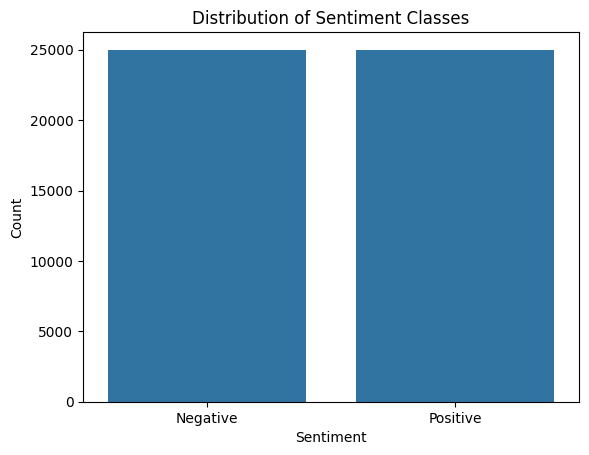

In [27]:
# Plot class distribution
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiment Classes")
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
# Download stopwords if not already present
nltk.download('stopwords')

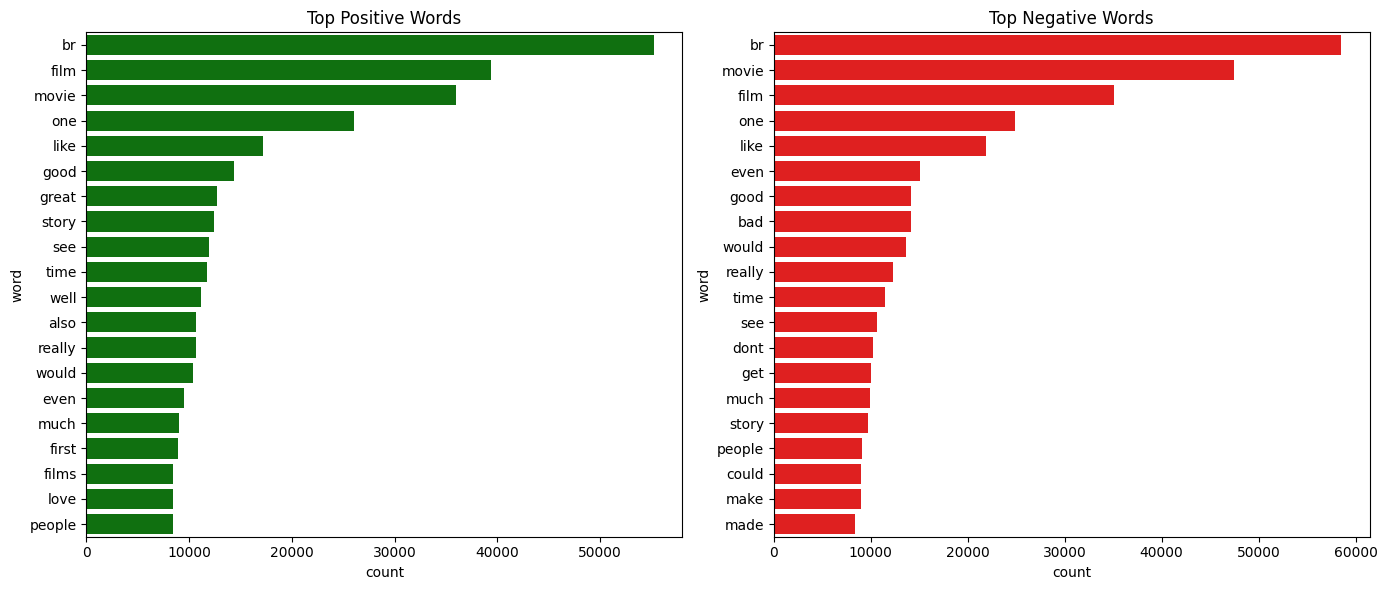

In [33]:
stop_words = set(stopwords.words('english'))

# Function to get top words excluding stopwords
def get_top_words(reviews, n=20):
    words = " ".join(reviews).lower().translate(str.maketrans("", "", string.punctuation)).split()
    words = [word for word in words if word not in stop_words]
    return Counter(words).most_common(n)

# Get top words for positive and negative reviews
top_pos_words = get_top_words(df[df['sentiment'] == 1]['review'])
top_neg_words = get_top_words(df[df['sentiment'] == 0]['review'])

# Convert to DataFrame for plotting
top_pos_df = pd.DataFrame(top_pos_words, columns=['word', 'count'])
top_neg_df = pd.DataFrame(top_neg_words, columns=['word', 'count'])

# Plot without deprecated 'palette' usage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x='count', y='word', data=top_pos_df, ax=axes[0], color="green")
axes[0].set_title("Top Positive Words")

sns.barplot(x='count', y='word', data=top_neg_df, ax=axes[1], color="red")
axes[1].set_title("Top Negative Words")

plt.tight_layout()
plt.show()

📌 Observation
The most frequent words in both positive and negative reviews include common terms like "movie" and "film", while positive reviews feature words like "great" and "love", and negative reviews include "bad" and "dont". This suggests basic sentiment cues and also highlights the need for further text cleaning (e.g., removing "br").

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 161s 321ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 0.8690 - val_loss: 1.0063
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 174s 348ms/step - accuracy: 0.9995 - loss: 0.0026 - val_accuracy: 0.8635 - val_loss: 1.0515
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 175s 349ms/step - accuracy: 0.9978 - loss: 0.0066 - val_accuracy: 0.8654 - val_loss: 1.0109
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 176s 351ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.8698 - val_loss: 1.0667
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 179s 357ms/step - accuracy: 0.9985 - loss: 0.0045 - val_accuracy: 0.8668 - val_loss: 1.0414


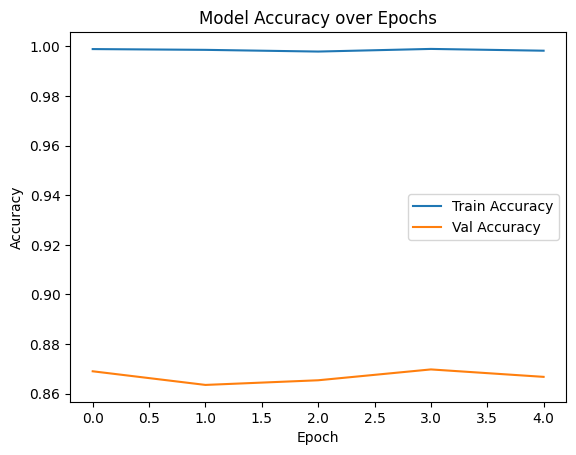

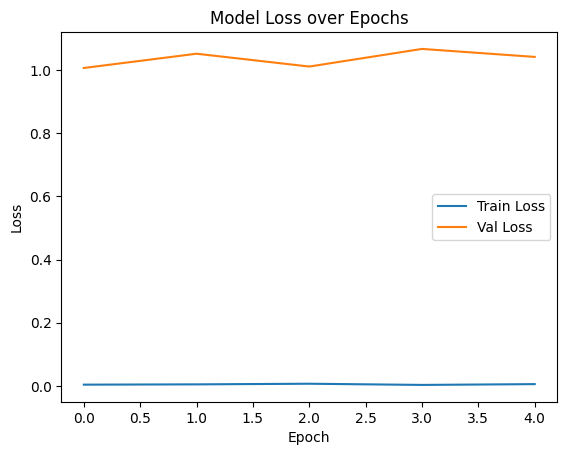

In [31]:
# Save training history
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()